In [99]:
import os
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import umap.umap_ as umap

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"]=(12,7)

In [133]:
from pathlib import Path
import pandas as pd
import csv

DATA_DIR = Path("../Data")

dfs = []

for file in sorted(DATA_DIR.glob("*.csv")):

    print(f"Loading {file.name}")

    rows = []

    with open(file, "r") as f:
        reader = csv.reader(f)

        header = next(reader)

        expected_cols = len(header)

        for row in reader:

            if len(row) == expected_cols:
                rows.append(row)

        df = pd.DataFrame(rows, columns=header)

    df["label"] = file.stem
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

Loading empty-room.csv
Loading OnePerson-sitting.csv
Loading OnePerson.csv
Loading TowPepole.csv
(61477, 262)


In [ ]:
df = df.dropna()

time = df["pc_time"]
labels = df["label"]

X = df.drop(columns=["pc_time", "label", "esp_time"])

print(X.shape)
print(labels.shape)
print(time.shape)

# چک نهایی
print("Total NaN:", X.isna().sum().sum())

(61477, 259)
(61477,)
(61477,)
Total NaN: 0


In [154]:
zero_cols=[]

for c in X.columns:
    if (X[c]==0).all():
        zero_cols.append(c)

print("Removed:",len(zero_cols))

X=X.drop(columns=zero_cols)

print(X.shape)

Removed: 0
(61477, 259)


In [190]:

scaler=StandardScaler()
X = X.apply(pd.to_numeric, errors="coerce")

X_scaled=scaler.fit_transform(X)

X_scaled=pd.DataFrame(X_scaled,columns=X.columns)
X_scaled
X_scaled = X_scaled.dropna()

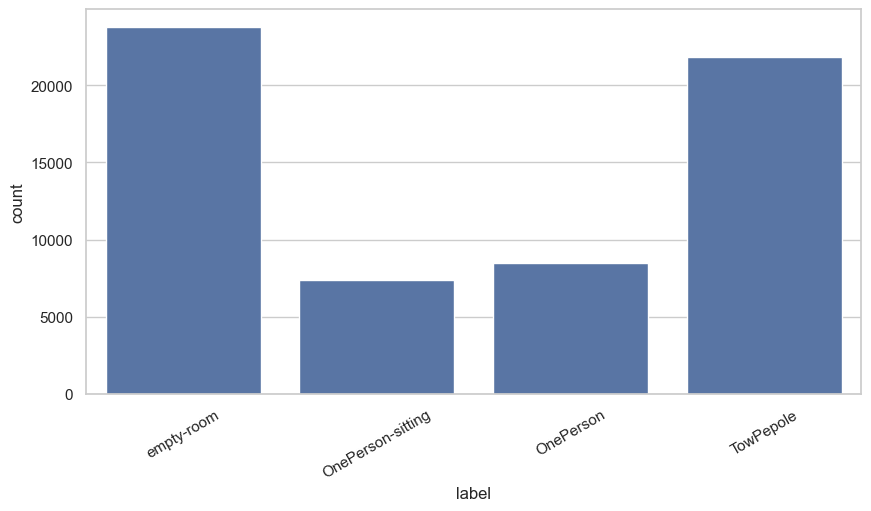

In [191]:
plt.figure(figsize=(10,5))

sns.countplot(x=labels)

plt.xticks(rotation=30)

plt.show()

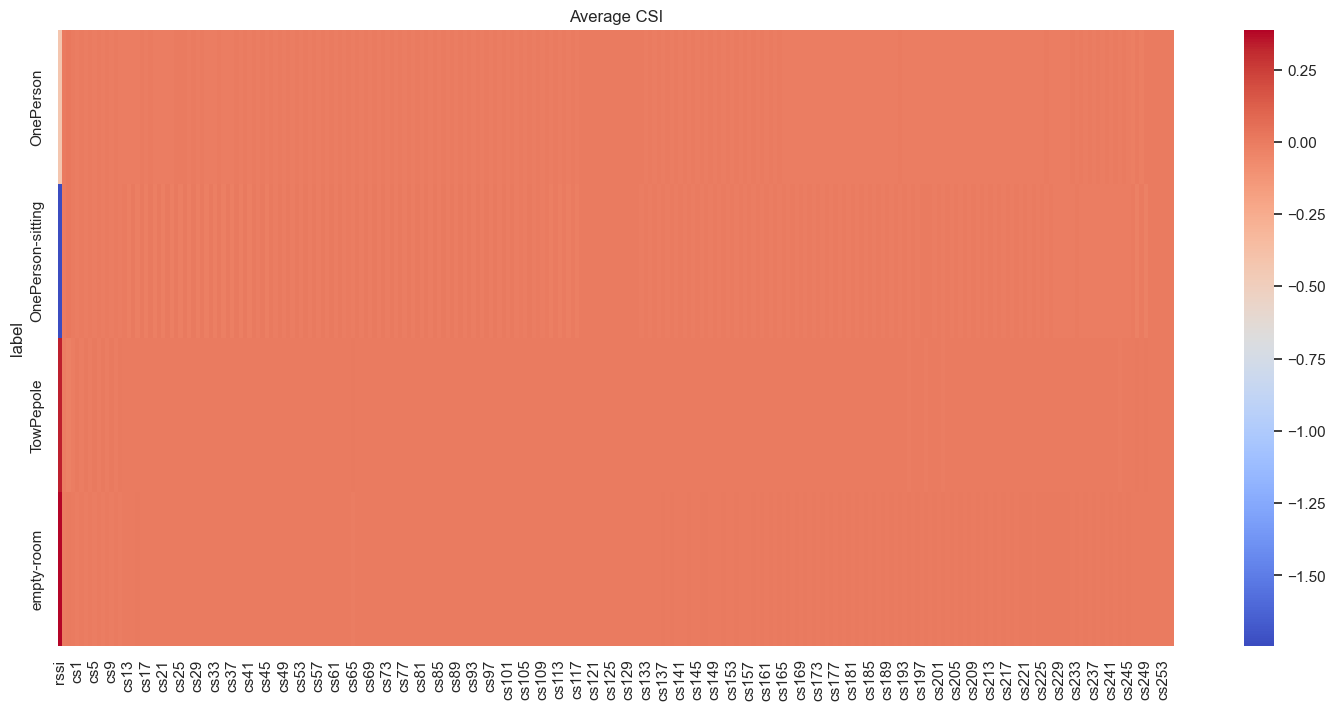

In [192]:
means=X_scaled.groupby(labels).mean()

plt.figure(figsize=(18,8))

sns.heatmap(means,cmap="coolwarm")

plt.title("Average CSI")

plt.show()

In [195]:
np.where(np.isnan(X_scaled.to_numpy()))
np.where(np.isinf(X_scaled.to_numpy()))


(array([], dtype=int64), array([], dtype=int64))

In [194]:
print(labels.shape)
labels= labels.drop([43107])
time=time.drop([43107])

(61476,)


KeyError: '[43107] not found in axis'

In [196]:
X_scaled.isna().sum().sum()

np.int64(0)

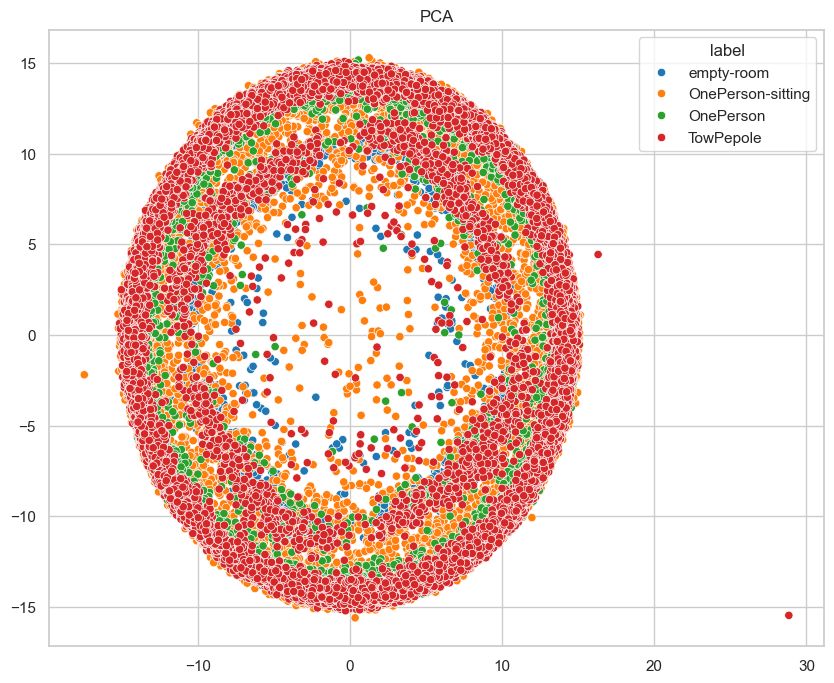

In [197]:
pca=PCA(n_components=2)
# print("Total NaN:", X_scaled.isna().sum().sum())
X_pca=pca.fit_transform(X_scaled)

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=labels,
    palette="tab10"
)

plt.title("PCA")

plt.show()

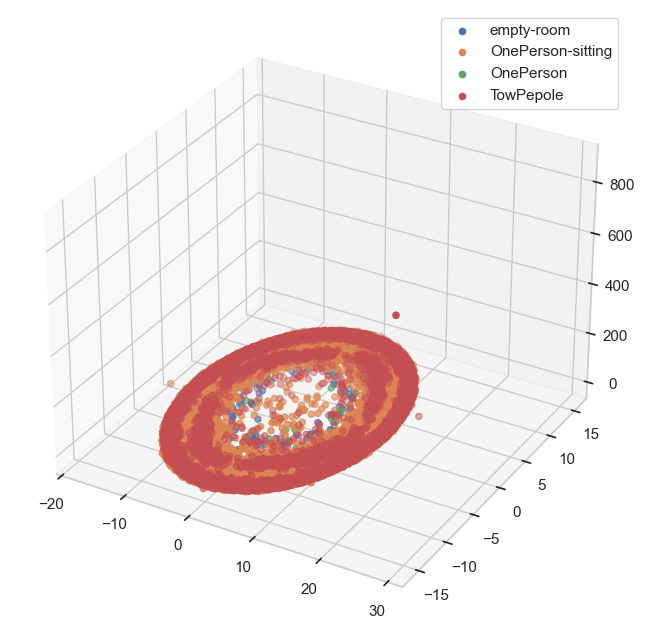

In [198]:
from mpl_toolkits.mplot3d import Axes3D

pca=PCA(n_components=3)

X3=pca.fit_transform(X_scaled)

fig=plt.figure(figsize=(10,8))

ax=fig.add_subplot(111,projection='3d')

for l in labels.unique():

    idx=labels==l

    ax.scatter(
        X3[idx,0],
        X3[idx,1],
        X3[idx,2],
        label=l,
        s=20
    )

plt.legend()

plt.show()

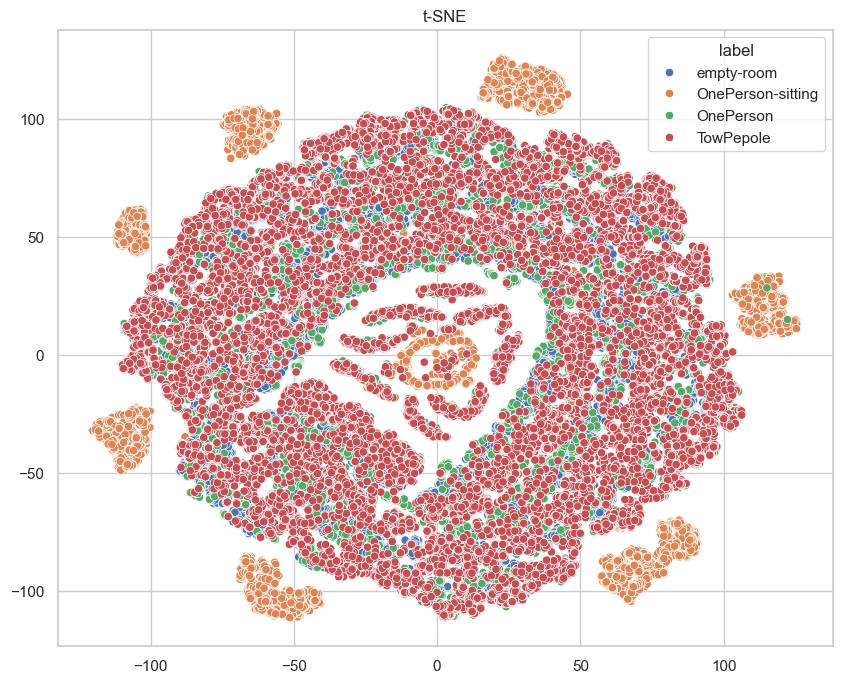

In [199]:
tsne=TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne=tsne.fit_transform(X_scaled)

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=labels
)

plt.title("t-SNE")

plt.show()

c:\Users\smhas\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


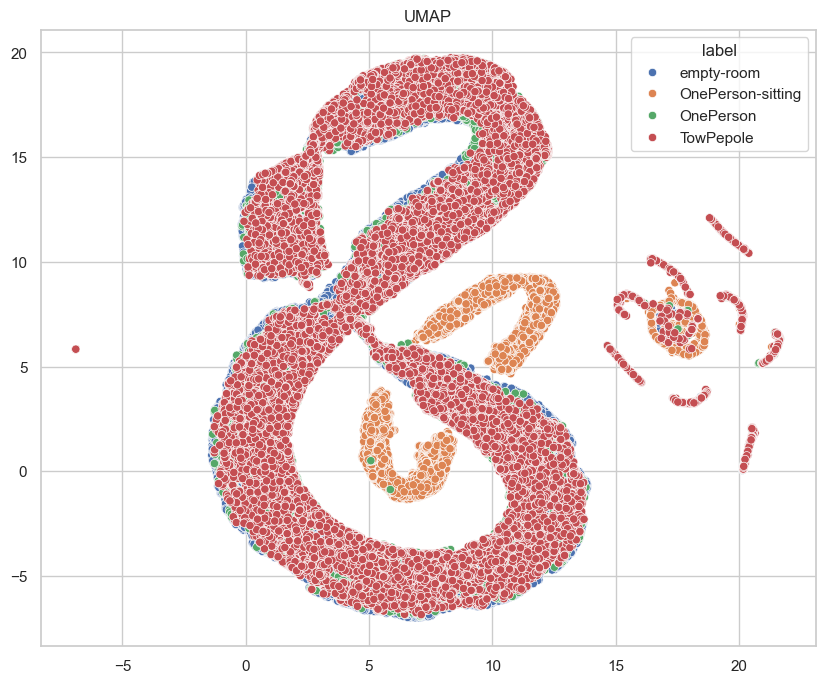

In [200]:
reducer=umap.UMAP(random_state=42)

embedding=reducer.fit_transform(X_scaled)

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=embedding[:,0],
    y=embedding[:,1],
    hue=labels
)

plt.title("UMAP")

plt.show()

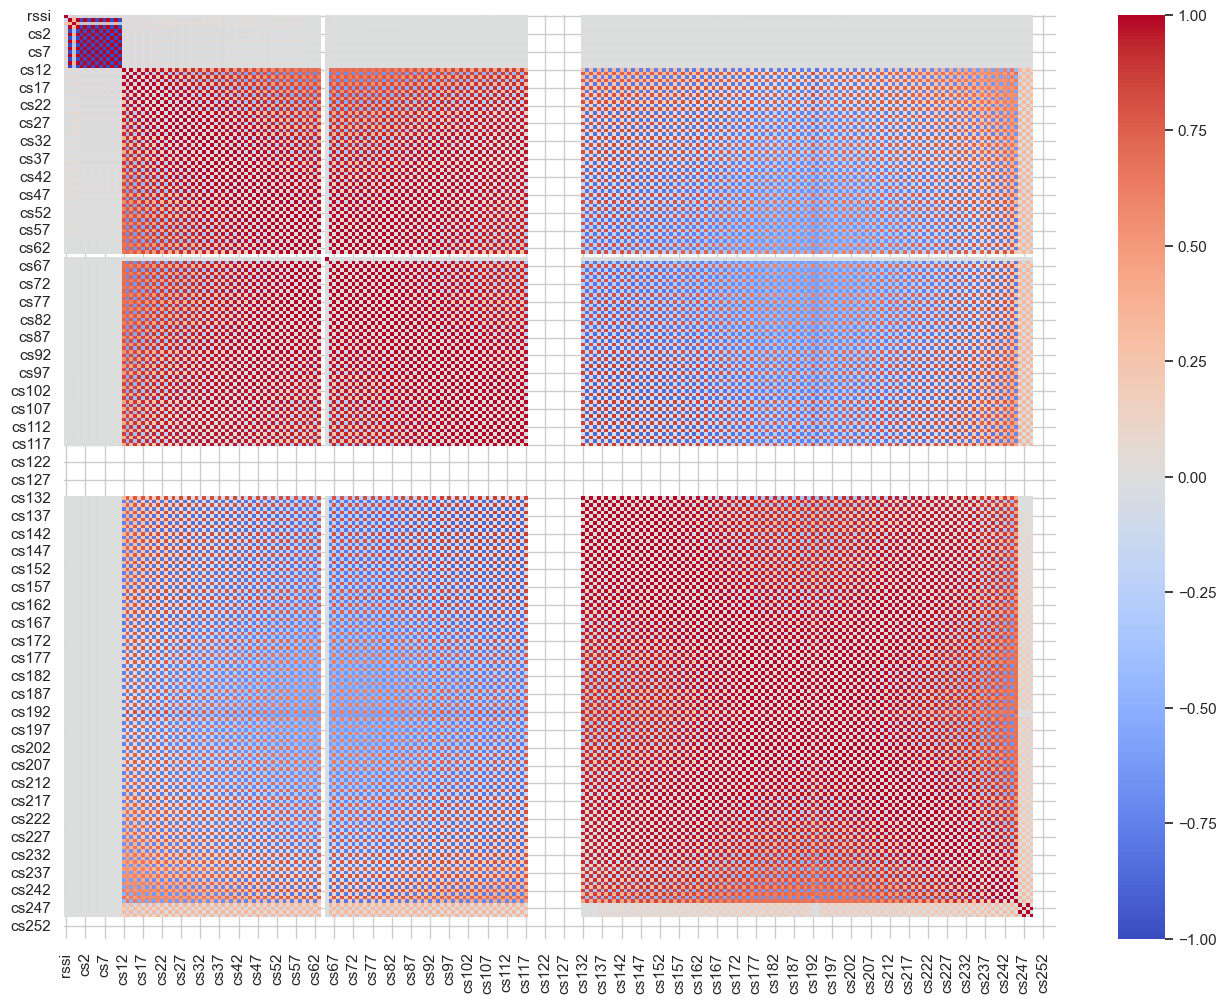

In [203]:
corr=X_scaled.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.show()

In [204]:
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

y=encoder.fit_transform(labels)

X_train,X_test,y_train,y_test=train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [205]:
rf=RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

pred=rf.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.84      0.43      0.57      1703
           1       0.99      1.00      1.00      1480
           2       0.81      0.87      0.84      4362
           3       0.86      0.95      0.90      4751

    accuracy                           0.86     12296
   macro avg       0.88      0.81      0.83     12296
weighted avg       0.86      0.86      0.85     12296



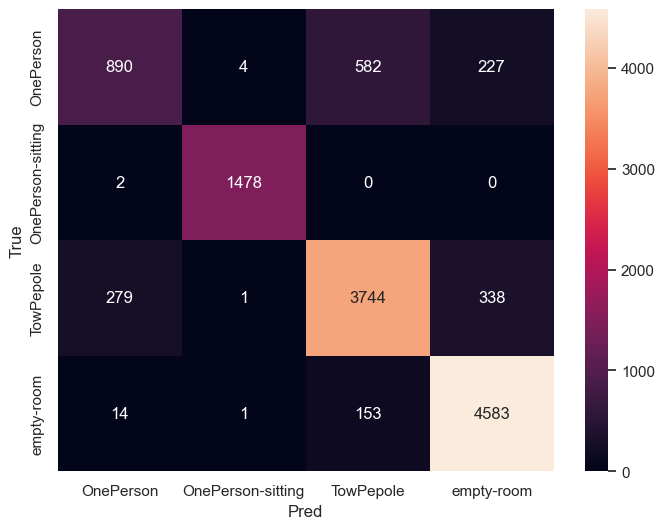

In [209]:
cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Pred")

plt.ylabel("True")

plt.show()

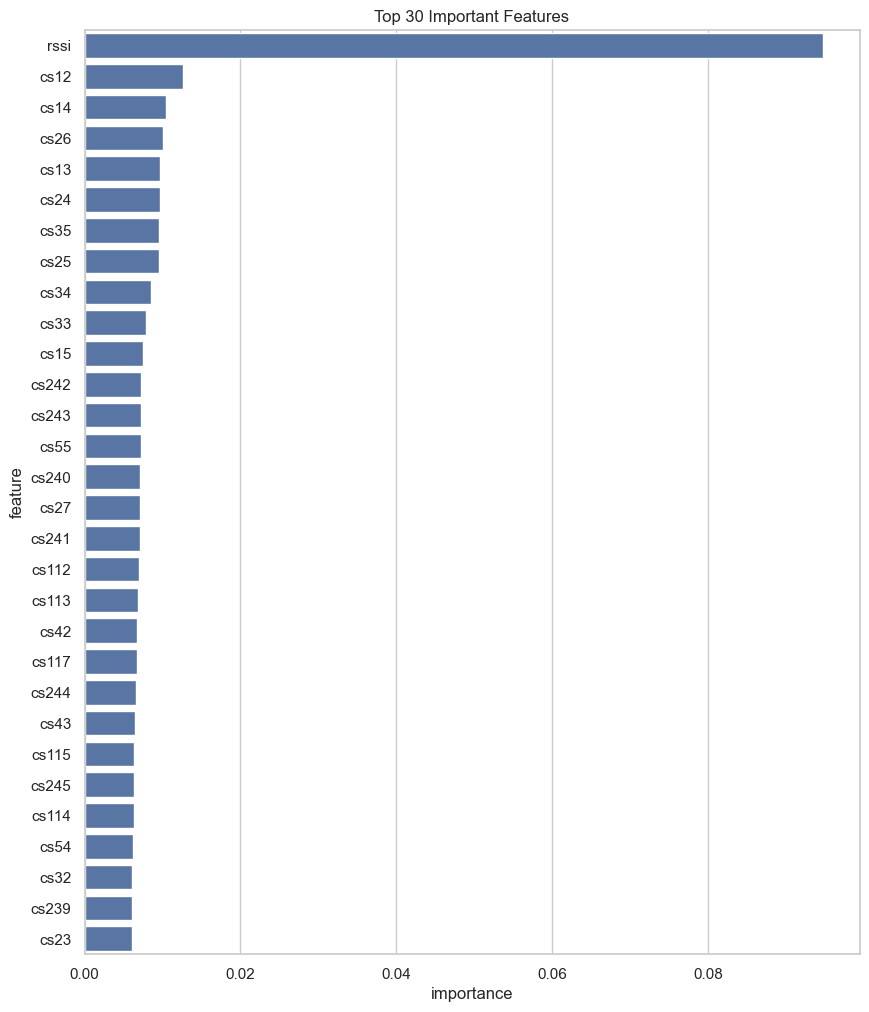

In [210]:
importance=pd.DataFrame({
    "feature":X.columns,
    "importance":rf.feature_importances_
})

importance=importance.sort_values(
    "importance",
    ascending=False
)

plt.figure(figsize=(10,12))

sns.barplot(
    data=importance.head(30),
    y="feature",
    x="importance"
)

plt.title("Top 30 Important Features")

plt.show()

In [ ]:
model=XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train,y_train)

pred=model.predict(X_test)
import joblib

joblib.dump(model, f"xgb_csi_model.pkl")
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.75      0.52      0.62      1703
           1       1.00      1.00      1.00      1480
           2       0.84      0.86      0.85      4362
           3       0.89      0.96      0.93      4751

    accuracy                           0.87     12296
   macro avg       0.87      0.84      0.85     12296
weighted avg       0.86      0.87      0.86     12296



In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

TypeError: 'value' must be an instance of str or bytes, not a float

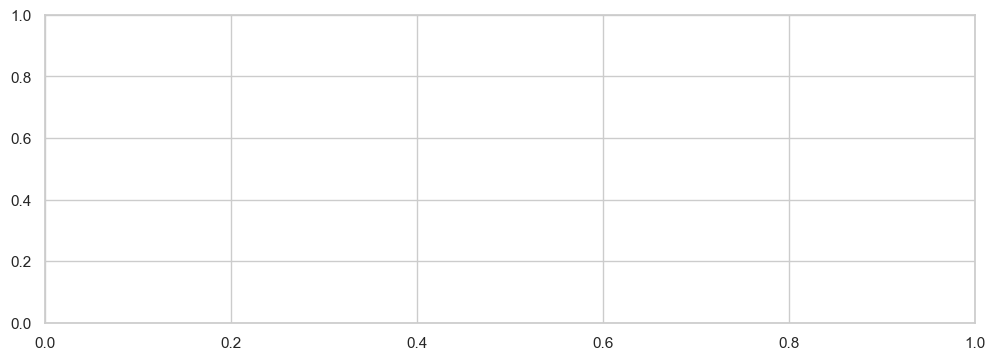

In [58]:
import matplotlib.pyplot as plt

sample = X.iloc[0].values

plt.figure(figsize=(12,4))
plt.plot(sample)
plt.title("CSI Snapshot (Single Packet)")
plt.xlabel("Subcarrier Index")
plt.ylabel("Amplitude / Phase")
plt.show()

In [ ]:
import numpy as np

window_size = 50

window = X.iloc[:window_size].values

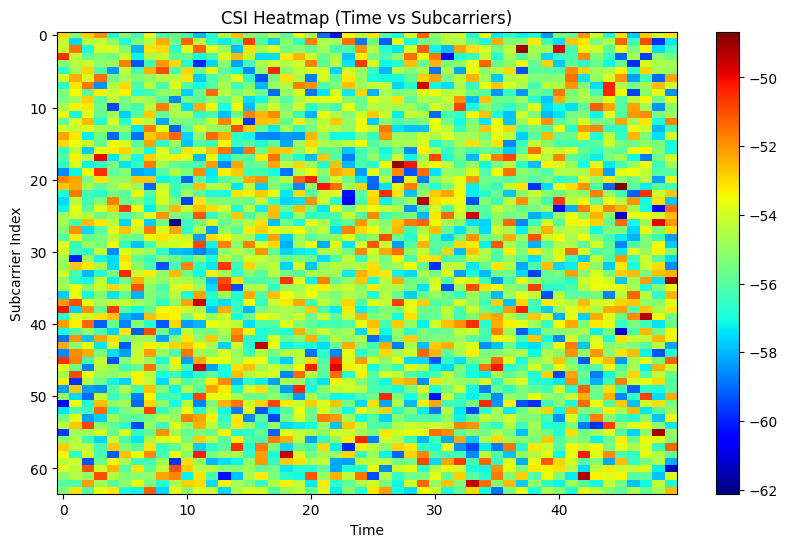

In [ ]:
plt.figure(figsize=(10,6))

plt.imshow(window.T, aspect='auto', cmap='jet')

plt.colorbar()
plt.title("CSI Heatmap (Time vs Subcarriers)")
plt.xlabel("Time")
plt.ylabel("Subcarrier Index")

plt.show()

In [ ]:
empty = df[df["label"] == 0].iloc[:50].drop("label", axis=1).values
human = df[df["label"] == 1].iloc[:50].drop("label", axis=1).values

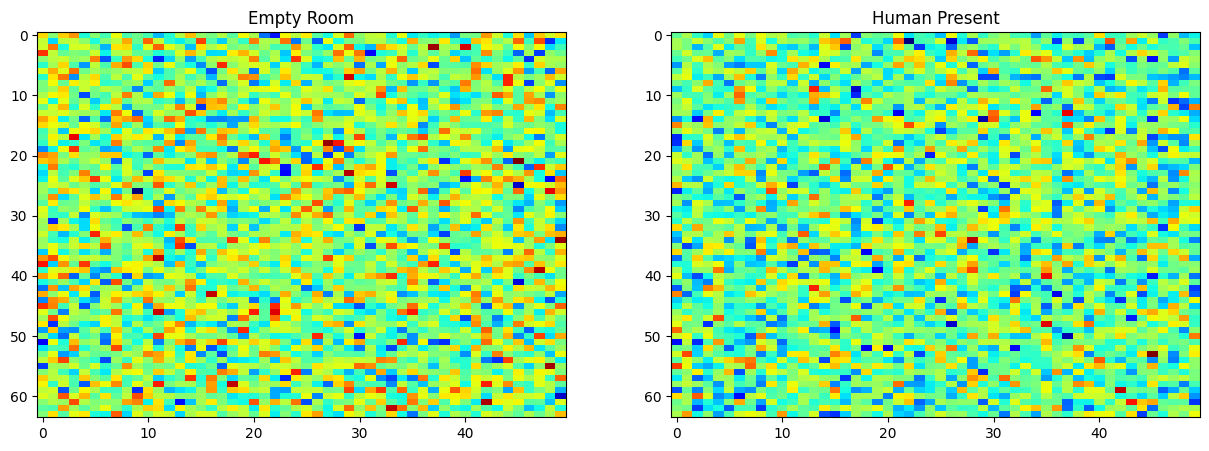

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].imshow(empty.T, aspect='auto', cmap='jet')
ax[0].set_title("Empty Room")

ax[1].imshow(human.T, aspect='auto', cmap='jet')
ax[1].set_title("Human Present")

plt.show()